# Tree sequences with RELATE

In [1]:
# load in the relevant packages
from matplotlib import pyplot as plt
import seaborn
import pandas as pd 
import numpy as np
from pathlib import Path

And a bit to make the plots look nicer in vscode:

In [2]:
%config InlineBackend.figure_format = 'svg'
from vscodenb import set_vscode_theme, vscode_theme
set_vscode_theme()
seaborn.set_palette('tab10')

If the sequences in your data set are individual haplotypes (they are phased), it is possible to construct the coalescence trees for each non-recombining segment of a genomic alignment. If you are working on male X chromosomes this is easy because they are haploid and do not require phasing. However, autosomes are diploid, and we would like to use haplotype-based analysis here as well. This can be done through either phasing of short reads mapped to a reference genome, or by assembing each haplotype `de novo` using long reads such as PacBio HiFi. Your chr2 data set is already phased so you are good to go.

In this exercise we will run the Relate program to infer local trees. In the upcomming exercises we will revisit this tree sequence and use it for inference of demography and selection. 

## Request an interactive session on a compute node:

Begin by requesting a shell on a compute node:

```bash
srun --mem-per-cpu=5g --time=3:00:00 --account=populationgenomics --pty pixi shell
```


## Data

The chr2 data for this exerise is from 60 individuals in the 1000Genomes project. There are 20 individuals from each of the following populations: GBR (British in England and Scotland), JPT (Japanese), YRI (Yoruban).

Create some symlinks that point to the following files:

In [ ]:
%%bash
ln -s ~/populationgenomics/data/relate_data/20140520.chr2.strict_mask.fasta
ln -s ~/populationgenomics/data/relate_data/genetic_map_chr2_combined_b37.txt
ln -s ~/populationgenomics/data/relate_data/human_ancestor_2.fa
ln -s ~/populationgenomics/data/relate_data/60_inds.txt
ln -s ~/populationgenomics/data/relate_data/chr2_130_145_phased.vcf.gz



This way it looks like the files are in your current folder. You can run `ls` to see them. The first file is a mask of genomic regions that either have abnormal read depth or contain repetitive elements. The second file is a recombination map. The third file is the ancestral state of every site, based on an alignment with gorilla, chimpanzee and human genomes. The fourth file is a metadata file detailing the population and region for each sample. The last file is the phased genotype VCF file.

The documentation for Relate can be found [here](https://myersgroup.github.io/relate/).

The `chr2_130_145_phased.vcf.gz` has individuals from three populations. To make tree sequences for each population, we first need to split the file into three files with samples from each population:

```bash
bcftools view --samples-file gbr_samples.txt --output chr2_130_145_gbr.vcf.gz chr2_130_145_phased.vcf.gz
bcftools view --samples-file jpt_samples.txt --output chr2_130_145_jpt.vcf.gz chr2_130_145_phased.vcf.gz
bcftools view --samples-file yri_samples.txt --output chr2_130_145_yri.vcf.gz chr2_130_145_phased.vcf.gz
```


> **NB:** Running Relate below, you should be aware that names of input files are always supplied without the file extensions.

Relate does not accept the standard VCF file format, but instead uses a haps/sample format. You can read up on in the Relate documentation. The authors have been so kind as to supply a script to transform it. First, the vcf is converted to another file format (haplotype file format). If you want to know how it is structured, you can read about it [here](https://www.cog-genomics.org/plink/2.0/formats#haps).

```bash
RelateFileFormats --mode ConvertFromVcf --haps gbr.haps --sample gbr.sample -i chr2_130_145_gbr
RelateFileFormats --mode ConvertFromVcf --haps jpt.haps --sample jpt.sample -i chr2_130_145_jpt
RelateFileFormats --mode ConvertFromVcf --haps yri.haps --sample yri.sample -i chr2_130_145_yri

```



Then, repetitive (unreliably sequenced) regions must be masked to exclude them form our analysis. We also need to assign each variant as either ancestral or derived using the chimpanzee genome. We do both with this command:

```bash
PrepareInputFiles.sh --haps gbr.haps --sample gbr.sample --ancestor human_ancestor_2.fa --mask 20140520.chr2.strict_mask.fasta -o gbr_input
PrepareInputFiles.sh --haps jpt.haps --sample jpt.sample --ancestor human_ancestor_2.fa --mask 20140520.chr2.strict_mask.fasta -o jpt_input
PrepareInputFiles.sh --haps yri.haps --sample yri.sample --ancestor human_ancestor_2.fa --mask 20140520.chr2.strict_mask.fasta -o yri_input
```

Inspect the generated files. 


**How many SNPs were removed in this filtering step?**

Hint: `cat chr2.haps | wc -l` counts the number of lines in `chr2.haps`. And `zcat` is `cat` for `.gz` files.


## Build trees along the genome

Now, the input is fully prepared, and Relate can be run. This should take less than a minute.

```bash
Relate --mode All -m 1.25e-8 -N 30000 --haps gbr_input.haps.gz --sample gbr_input.sample.gz --map genetic_map_chr2_combined_b37.txt -o gbr_relate
Relate --mode All -m 1.25e-8 -N 30000 --haps jpt_input.haps.gz --sample jpt_input.sample.gz --map genetic_map_chr2_combined_b37.txt -o jpt_relate
Relate --mode All -m 1.25e-8 -N 30000 --haps yri_input.haps.gz --sample yri_input.sample.gz --map genetic_map_chr2_combined_b37.txt -o yri_relate
```

**How many SNPs are left per haplotype?**


## Estimate historical population size and reestimate branch lengths of trees

The lengthiest process is this step, in which population size is estimated, and the population size is re-estimates branch lengths. This takes around 20 minutes. While you are waiting, explain to a fellow student how an ARG can be constructed backwards in time and how it can be constructed along the sequence. If time permits, make sure to also explain how the SMC and SMC' models approximate the ARG.

```bash
EstimatePopulationSize.sh -i gbr_relate -m 1.25e-8 --poplabels gbr_inds.txt -o popsize --threshold 0
EstimatePopulationSize.sh -i jpt_relate -m 1.25e-8 --poplabels jpt_inds.txt -o popsize --threshold 0
EstimatePopulationSize.sh -i yri_relate -m 1.25e-8 --poplabels yri_inds.txt -o popsize --threshold 0
```

Relate outputs estimated mutation rate and coalescence times along the region

Using the `--pop_of_interest` flag you can isolate specific populations and see their population size back through time.

**Look at the files and see what you learn?**

## Visualizing trees with tskit

Convert the Relate output to tree sequence format:

```bash
RelateFileFormats --mode ConvertToTreeSequence -i chr2_relate -o chr2_relate
```

In [51]:
import tskit

# load the tree sequence
ts = tskit.load("chr2_relate.trees")

In [52]:
tree = ts.at_index(0)  # first tree
tree

In [53]:

tree = ts.at(1_000_000)  # tree at a specific base pair position
tree

Here are some ways to visualize trees. You can plot them with matplotlib (good with dark mode):

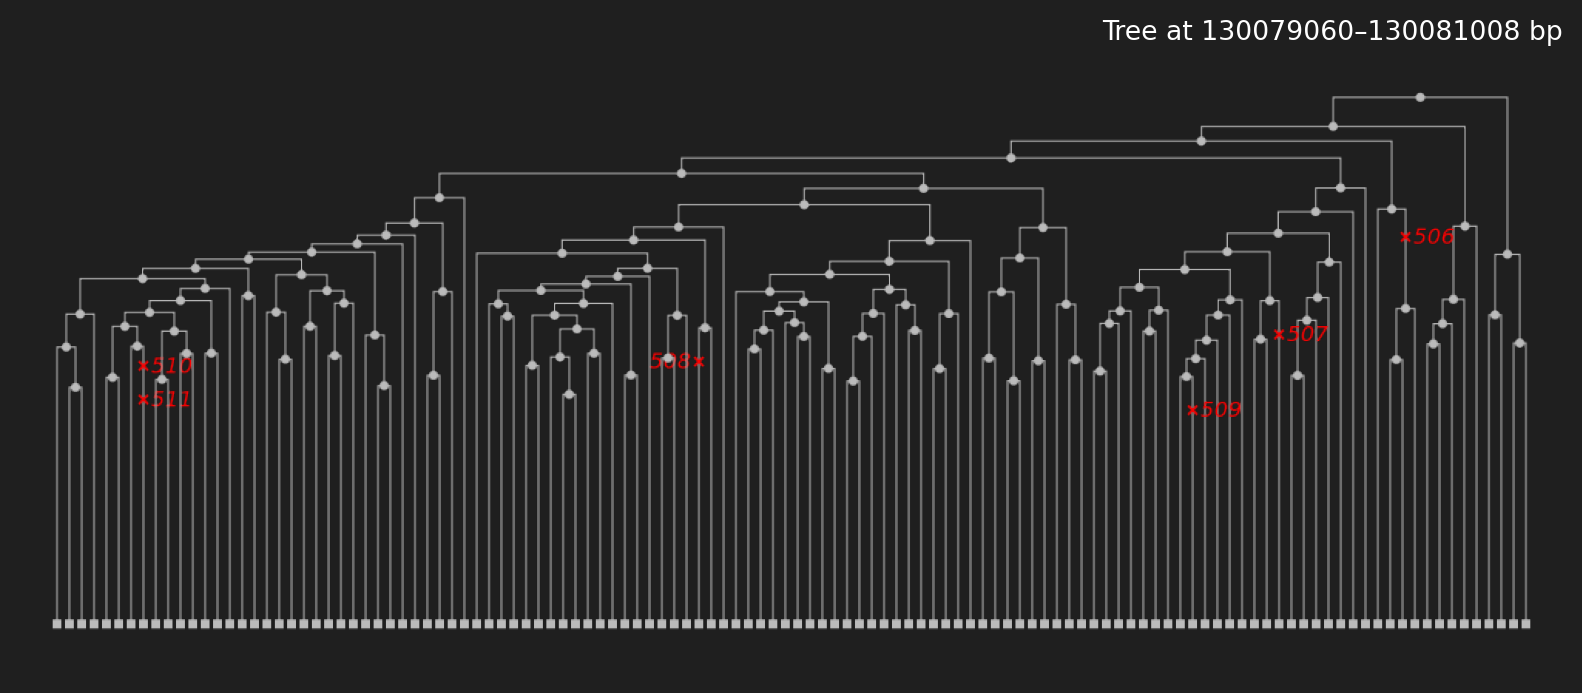

In [65]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.offsetbox import AnnotationBbox
import io

import cairosvg
from PIL import Image

def draw_tree_on_ax(tree, ax, time_scale="log_time", node_labels={}):
    svg = tree.draw_svg(
        size=(1000, 400),
        time_scale=time_scale,
        node_labels=node_labels,
        style = "path.edge { stroke: #bbbbbb } .node .sym { fill: #bbbbbb }"
    )
    # Convert SVG -> PNG in memory
    png_data = cairosvg.svg2png(bytestring=svg.encode())
    img = Image.open(io.BytesIO(png_data))
    ax.imshow(img)
    ax.axis("off")

fig, ax = plt.subplots(figsize=(8, 5))
draw_tree_on_ax(tree, ax)
ax.set_title(f"Tree at {tree.interval.left:.0f}–{tree.interval.right:.0f} bp")
plt.tight_layout()
plt.savefig("tree_0.png", dpi=150)
plt.show()


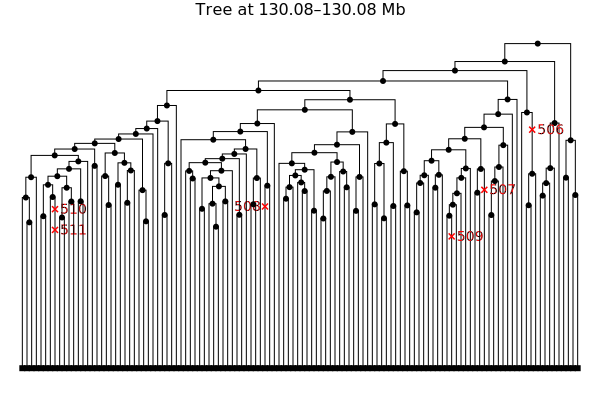

In [55]:
from IPython.display import SVG, display, clear_output
from time import sleep

ts = tskit.load("chr2_relate.trees")

for i in range(30):
    tree = ts.at_index(i)
    svg = tree.draw_svg(
        size=(600, 400),
        time_scale="log_time",
        node_labels={},
        title=f"Tree at {tree.interval.left/1e6:.2f}–{tree.interval.right/1e6:.2f} Mb",
    )
    display(SVG(svg))
    sleep(1)
    clear_output(wait=True)

Draw trees 10 through 15 in a grid, with intervals as labels

In [69]:
from IPython.display import HTML

svgs = []
for i in range(10, 16):
    tree = ts.at_index(i)
    svg = tree.draw_svg(
        size=(600, 250),
        time_scale="log_time",
        node_labels={},
        style = "path.edge { stroke: #bbbbbb } .node .sym { fill: #bbbbbb }"
    )
    label = f"<p>{tree.interval.left/1e3:.0f}–{tree.interval.right/1e3:.0f} kb</p>"
    svgs.append(f"<div style='display:inline-block;margin:5px'>{label}{svg}</div>")

display(HTML("<div>" + "".join(svgs) + "</div>"))

**Try to view some trees close to each other and far from each other. Are close trees the same, why?**

**Do trees become more different the further away from each other they are, why?**

**How often do individuals from the same population form a single group? What does that tell you about lineage sorting in humans?**

**See if you can find out where the lactase gene is and see what the trees look like there.**